In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

Sat May  2 03:15:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics datasets pillow tqdm pyyaml opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.2 MB/s eta 0:00:00


In [ ]:
import os
import shutil
from pathlib import Path

import yaml
from tqdm import tqdm
from datasets import load_dataset
from PIL import Image

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Create project folders

In [ ]:
BASE_DIR = Path("/content/drone_baseline")
DATASET_DIR = BASE_DIR / "public_drone_yolo"

for split in ["train", "val", "test"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print(DATASET_DIR)

/content/drone_baseline/public_drone_yolo


Download public dataset from Hugging Face

In [ ]:
ds = load_dataset("pathikg/drone-detection-dataset")

print(ds)
print(ds["train"][0].keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/491M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/495M [00:00<?, ?B/s]

data/train-00002-of-00009.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

...

data/train-00008-of-00009.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51446 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2625 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['width', 'height', 'objects', 'image', 'image_id'],
        num_rows: 51446
    })
    test: Dataset({
        features: ['width', 'height', 'objects', 'image', 'image_id'],
        num_rows: 2625
    })
})
dict_keys(['width', 'height', 'objects', 'image', 'image_id'])


Split train into train/validation/test

In [ ]:
DEBUG = True

# Use small subset first to confirm the pipeline works.
# Later set DEBUG = False for the real baseline.
if DEBUG:
    MAX_TRAIN = 5000
    MAX_VAL = 1000
    MAX_TEST = 1000
else:
    MAX_TRAIN = None
    MAX_VAL = None
    MAX_TEST = None

split_ds = ds["train"].train_test_split(test_size=0.1, seed=42)

train_ds = split_ds["train"]
val_ds = split_ds["test"]
test_ds = ds["test"]

def limit_dataset(dataset, max_items):
    if max_items is None:
        return dataset
    return dataset.select(range(min(max_items, len(dataset))))

train_ds = limit_dataset(train_ds, MAX_TRAIN)
val_ds = limit_dataset(val_ds, MAX_VAL)
test_ds = limit_dataset(test_ds, MAX_TEST)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 5000
Val: 1000
Test: 1000


Convert COCO boxes to YOLO format

In [ ]:
def coco_to_yolo_bbox(bbox, img_w, img_h):
    """
    COCO bbox: [x_min, y_min, width, height]
    YOLO bbox: [x_center_norm, y_center_norm, width_norm, height_norm]
    """
    x, y, w, h = bbox

    x_center = x + w / 2
    y_center = y + h / 2

    x_center /= img_w
    y_center /= img_h
    w /= img_w
    h /= img_h

    return x_center, y_center, w, h


def save_split_to_yolo(dataset, split_name, output_dir):
    image_dir = output_dir / "images" / split_name
    label_dir = output_dir / "labels" / split_name

    for idx, item in enumerate(tqdm(dataset, desc=f"Converting {split_name}")):
        image = item["image"].convert("RGB")

        img_w = item.get("width", image.width)
        img_h = item.get("height", image.height)

        image_filename = f"{split_name}_{idx:06d}.jpg"
        label_filename = f"{split_name}_{idx:06d}.txt"

        image_path = image_dir / image_filename
        label_path = label_dir / label_filename

        image.save(image_path, quality=95)

        objects = item["objects"]
        bboxes = objects["bbox"]

        label_lines = []

        for bbox in bboxes:
            x_center, y_center, w, h = coco_to_yolo_bbox(bbox, img_w, img_h)

            # Skip invalid boxes
            if w <= 0 or h <= 0:
                continue

            # Clip values safely
            x_center = min(max(x_center, 0), 1)
            y_center = min(max(y_center, 0), 1)
            w = min(max(w, 0), 1)
            h = min(max(h, 0), 1)

            class_id = 0  # drone
            label_lines.append(
                f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
            )

        with open(label_path, "w") as f:
            f.write("\n".join(label_lines))

Run conversion

In [ ]:
save_split_to_yolo(train_ds, "train", DATASET_DIR)
save_split_to_yolo(val_ds, "val", DATASET_DIR)
save_split_to_yolo(test_ds, "test", DATASET_DIR)

Converting test: 100%|██████████| 1000/1000 [00:05<00:00, 171.59it/s]


Create YOLO dataset YAML

In [ ]:
data_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "drone"
    }
}

yaml_path = DATASET_DIR / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(yaml_path)

with open(yaml_path, "r") as f:
    print(f.read())

/content/drone_baseline/public_drone_yolo/data.yaml
path: /content/drone_baseline/public_drone_yolo
train: images/train
val: images/val
test: images/test
names:
  0: drone



Visual check of one converted image

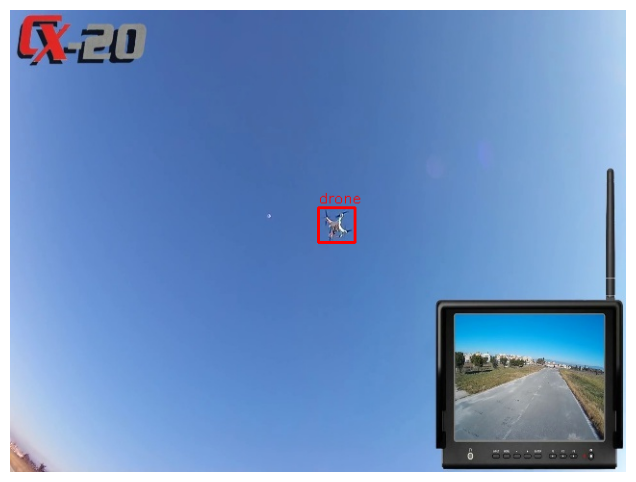

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

def visualize_yolo_sample(split="train"):
    image_dir = DATASET_DIR / "images" / split
    label_dir = DATASET_DIR / "labels" / split

    image_files = list(image_dir.glob("*.jpg"))
    img_path = random.choice(image_files)
    label_path = label_dir / f"{img_path.stem}.txt"

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.read().strip().splitlines()

        for line in lines:
            if not line.strip():
                continue

            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(
                img,
                "drone",
                (x1, max(y1 - 5, 0)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                1
            )

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

visualize_yolo_sample("train")

Train YOLO11 baseline

In [ ]:
model = YOLO("yolo11n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=30 if DEBUG else 100,
    imgsz=960,
    batch=8,
    device=0,
    workers=2,
    project=str(BASE_DIR / "runs"),
    name="yolo11n_public_drone_baseline",
    patience=10,
    save=True
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drone_baseline/public_drone_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_public_drone_baseline, nbs=64, nms=False, opset=None, optimize=False, optimi

Validate on public test set

In [ ]:
best_model_path = BASE_DIR / "runs" / "yolo11n_public_drone_baseline" / "weights" / "best.pt"

model = YOLO(str(best_model_path))

metrics = model.val(
    data=str(yaml_path),
    split="test",
    imgsz=960,
    conf=0.25,
    iou=0.5,
    project=str(BASE_DIR / "runs"),
    name="public_test_evaluation"
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1324.8±402.9 MB/s, size: 124.1 KB)
val: Scanning /content/drone_baseline/public_drone_yolo/labels/test... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 1.6Kit/s 0.6s
val: New cache created: /content/drone_baseline/public_drone_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.0it/s 15.9s
                   all       1000       1083      0.894      0.795      0.783      0.348
Speed: 3.2ms preprocess, 6.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/drone_baseline/runs/public_test_evaluation


In [ ]:
print(metrics)

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x786716d6d940>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Run prediction on public test images

In [ ]:
pred_results = model.predict(
    source=str(DATASET_DIR / "images" / "test"),
    imgsz=960,
    conf=0.25,
    save=True,
    project=str(BASE_DIR / "runs"),
    name="public_test_predictions"
)


image 1/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000000.jpg: 736x960 1 drone, 52.3ms
image 2/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000001.jpg: 736x960 1 drone, 11.3ms
image 3/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000002.jpg: 736x960 1 drone, 11.2ms
image 4/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000003.jpg: 736x960 1 drone, 11.3ms
image 5/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000004.jpg: 736x960 1 drone, 11.3ms
image 6/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000005.jpg: 736x960 1 drone, 11.3ms
image 7/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000006.jpg: 736x960 1 drone, 11.3ms
image 8/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000007.jpg: 736x960 1 drone, 11.2ms
image 9/1000 /content/drone_baseline/public_drone_yolo/images/test/test_000008.jpg: 736x960 (no detections), 11.2ms
image 10/1000 /cont

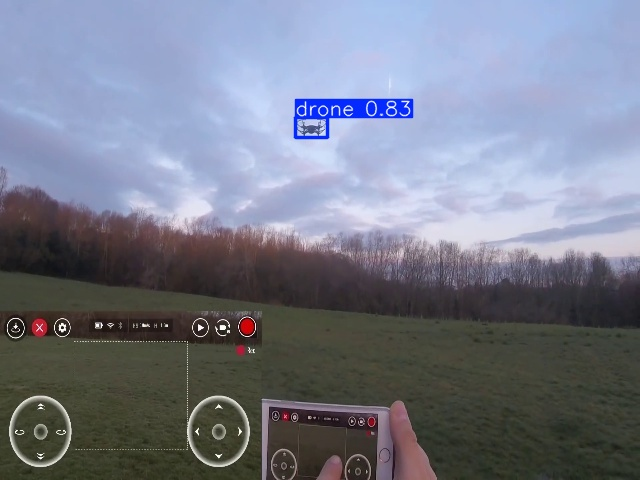

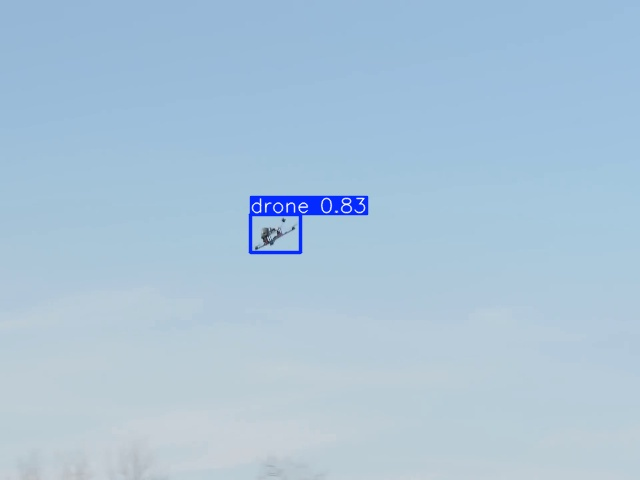

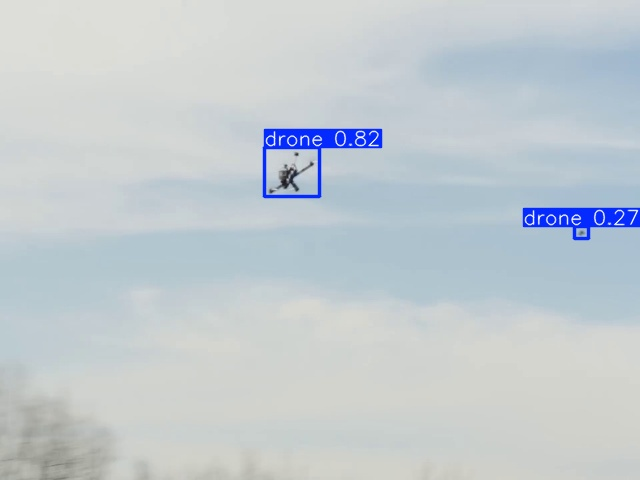

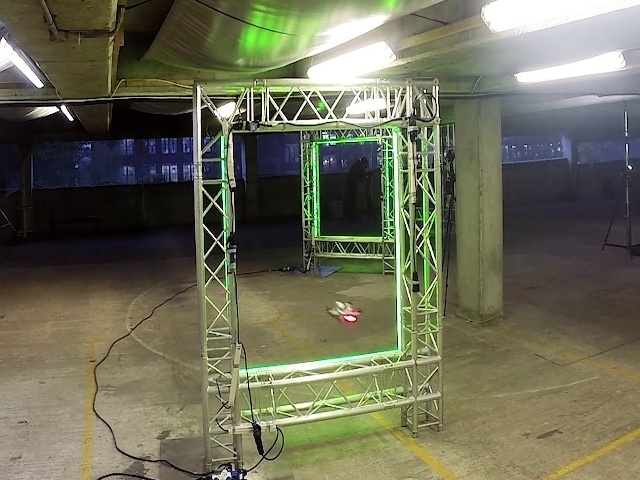

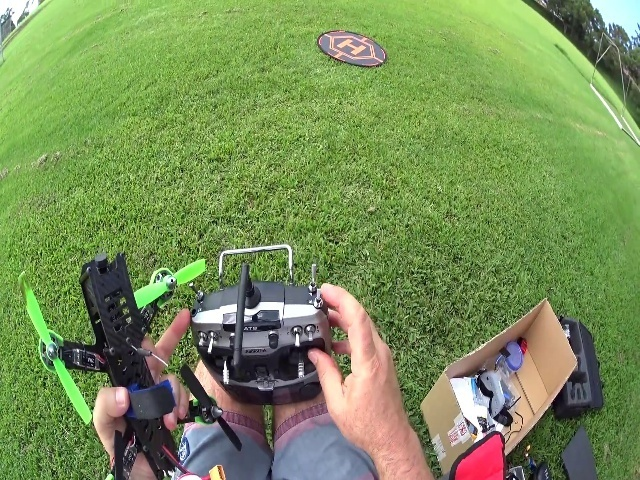

In [ ]:
from IPython.display import Image as IPImage, display

pred_dir = BASE_DIR / "runs" / "public_test_predictions"
pred_images = list(pred_dir.glob("*.jpg"))

for img_path in pred_images[:5]:
    display(IPImage(filename=str(img_path)))

Upload local videos

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
LOCAL_VIDEO_DIR = Path("/content/drive/MyDrive/local_drone_videos")
print(list(LOCAL_VIDEO_DIR.iterdir()))

[PosixPath('/content/drive/MyDrive/local_drone_videos/Vid5.mp4'), PosixPath('/content/drive/MyDrive/local_drone_videos/Vid4.mp4'), PosixPath('/content/drive/MyDrive/local_drone_videos/Vid3.mp4'), PosixPath('/content/drive/MyDrive/local_drone_videos/Vid2.mp4'), PosixPath('/content/drive/MyDrive/local_drone_videos/Vid1.mp4')]


Predict on your local videos

In [33]:
from ultralytics import YOLO
from pathlib import Path
import torch
import gc

BASE_DIR = Path("/content/drone_baseline")
LOCAL_VIDEO_DIR = Path("/content/drive/MyDrive/local_drone_videos/")

best_model_path = BASE_DIR / "runs" / "yolo11n_public_drone_baseline" / "weights" / "best.pt"
model = YOLO(str(best_model_path))

video_extensions = ["*.mp4", "*.mov", "*.avi", "*.mkv"]

video_files = []
for ext in video_extensions:
    video_files.extend(list(LOCAL_VIDEO_DIR.glob(ext)))

video_files = sorted(video_files)

print("Found videos:")
for v in video_files:
    print(v.name)

OUTPUT_BASE = BASE_DIR / "runs" / "public_baseline_on_local_videos_safe"

for video_path in video_files:
    print(f"\nProcessing: {video_path.name}")

    results_generator = model.predict(
        source=str(video_path),
        imgsz=640,          # use 640 first; later try 960
        conf=0.25,
        device=0,
        batch=1,
        stream=True,        # important: does not keep all results in memory
        save=True,
        save_txt=True,
        save_conf=True,
        project=str(OUTPUT_BASE),
        name=video_path.stem,
        exist_ok=True,
        verbose=False,
        vid_stride=2        # processes every 2nd frame; reduce RAM and time
    )

    # Consume generator without storing results
    for _ in results_generator:
        pass

    gc.collect()
    torch.cuda.empty_cache()

print("Done.")

Found videos:
Vid1.mp4
Vid2.mp4
Vid3.mp4
Vid4.mp4
Vid5.mp4

Processing: Vid1.mp4
Results saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid1
1779 labels saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid1/labels

Processing: Vid2.mp4
Results saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid2
180 labels saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid2/labels

Processing: Vid3.mp4
Results saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid3
963 labels saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid3/labels

Processing: Vid4.mp4
Results saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid4
499 labels saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid4/labels

Processing: Vid5.mp4
Results saved to /content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid

In [ ]:
print(BASE_DIR / "runs" / "public_baseline_on_local_videos_safe" / "Vid10")

/content/drone_baseline/runs/public_baseline_on_local_videos_safe/Vid10


In [ ]:
!du -sh /content/drone_baseline

3.0G	/content/drone_baseline


In [34]:
import shutil
from google.colab import files

SOURCE_DIR = "/content/drone_baseline/runs/public_baseline_on_local_videos_safe"
ZIP_BASE = "/content/drone_baseline_vid_data_full_backup"

shutil.make_archive(ZIP_BASE, "zip", SOURCE_DIR)

files.download(ZIP_BASE + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Zip the results for download

In [ ]:
OUTPUT_DIR = BASE_DIR / "runs" / "public_baseline_on_local_videos"
ZIP_PATH = "/content/public_baseline_on_local_videos.zip"

!zip -r "{ZIP_PATH}" "{OUTPUT_DIR}"